In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/Predictive Modelling/ottdata.csv'

df = pd.read_csv(file_path)


In [14]:
print("DataFrame Information (columns, non-null counts, data types):")
df.info()
print(df.shape)

DataFrame Information (columns, non-null counts, data types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB
(1000, 8)


In [15]:
df.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


In [16]:
print("Descriptive statistics for numerical columns:")
df.describe()

Descriptive statistics for numerical columns:


,visitors,ad_impressions,major_sports_event,views_trailer,views_content
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,1.704290,1434.712290,0.400000,66.91559,0.473400
std,0.231973,289.534834,0.490143,35.00108,0.105914
min,1.250000,1010.870000,0.000000,30.08000,0.220000
25%,1.550000,1210.330000,0.000000,50.94750,0.400000
50%,1.700000,1383.580000,0.000000,53.96000,0.450000
75%,1.830000,1623.670000,1.000000,57.75500,0.520000
max,2.340000,2424.200000,1.000000,199.92000,0.890000


In [17]:
print("Descriptive statistics for all columns (including categorical):")
df.describe(include='all')

Descriptive statistics for all columns (including categorical):


,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
count,1000.000000,1000.000000,1000.000000,1000,1000,1000,1000.00000,1000.000000
unique,NaN,NaN,NaN,8,7,4,NaN,NaN
top,NaN,NaN,NaN,Others,Friday,Winter,NaN,NaN
freq,NaN,NaN,NaN,255,369,257,NaN,NaN
mean,1.704290,1434.712290,0.400000,NaN,NaN,NaN,66.91559,0.473400
std,0.231973,289.534834,0.490143,NaN,NaN,NaN,35.00108,0.105914
min,1.250000,1010.870000,0.000000,NaN,NaN,NaN,30.08000,0.220000
25%,1.550000,1210.330000,0.000000,NaN,NaN,NaN,50.94750,0.400000
50%,1.700000,1383.580000,0.000000,NaN,NaN,NaN,53.96000,0.450000
75%,1.830000,1623.670000,1.000000,NaN,NaN,NaN,57.75500,0.520000


In [18]:
print(df.isnull().sum())

visitors              0
ad_impressions        0
major_sports_event    0
genre                 0
dayofweek             0
season                0
views_trailer         0
views_content         0
dtype: int64


In [19]:
print("\n----- Descriptive Statistics (Categorical) -----")
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


----- Descriptive Statistics (Categorical) -----

Column: genre
genre
Others      255
Comedy      114
Thriller    113
Drama       109
Romance     105
Sci-Fi      102
Horror      101
Action      101
Name: count, dtype: int64

Column: dayofweek
dayofweek
Friday       369
Wednesday    332
Thursday      97
Saturday      88
Sunday        67
Monday        24
Tuesday       23
Name: count, dtype: int64

Column: season
season
Winter    257
Fall      252
Spring    247
Summer    244
Name: count, dtype: int64


Visualizing numerical column distributions (Histograms and Box Plots):


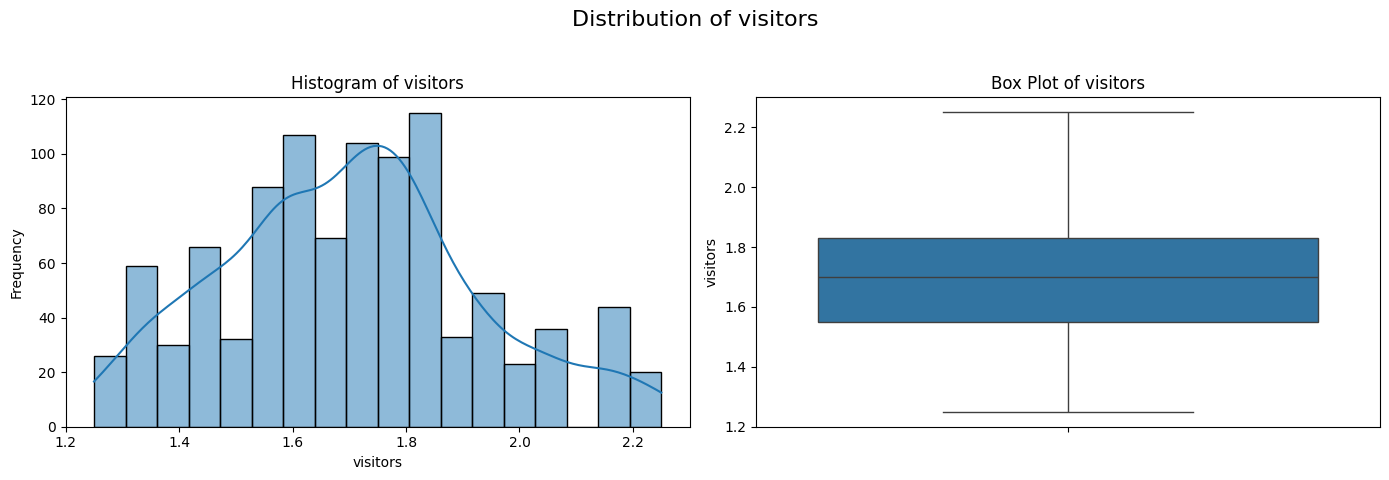

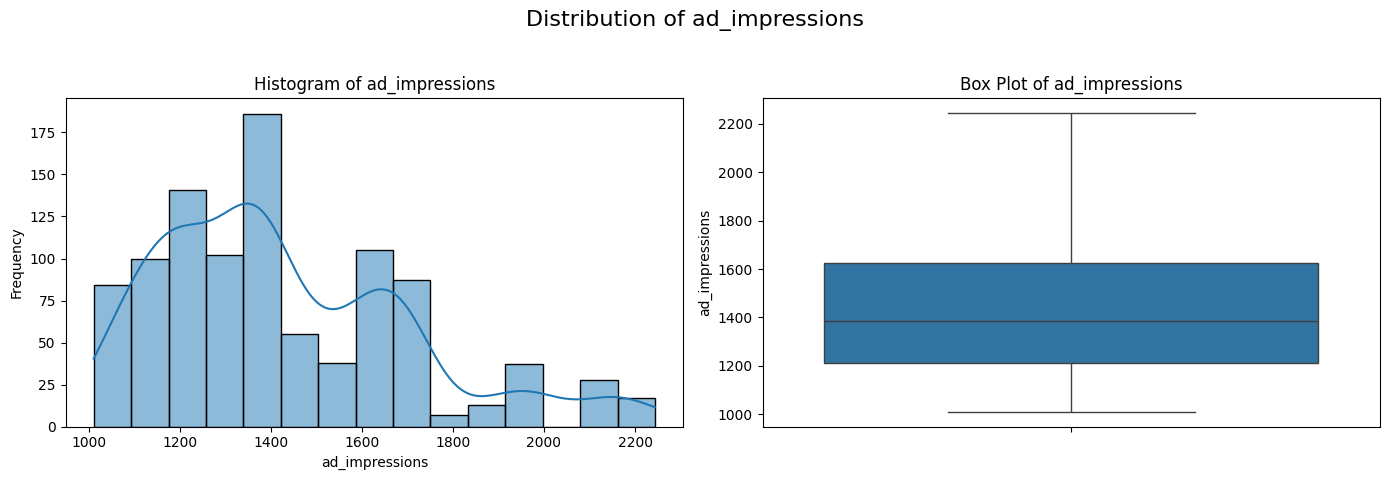

Skipping detailed numerical plot for 'major_sports_event' as it has few unique values (might be categorical in nature).
Value counts for 'major_sports_event':
major_sports_event
0    600
1    400
Name: count, dtype: int64



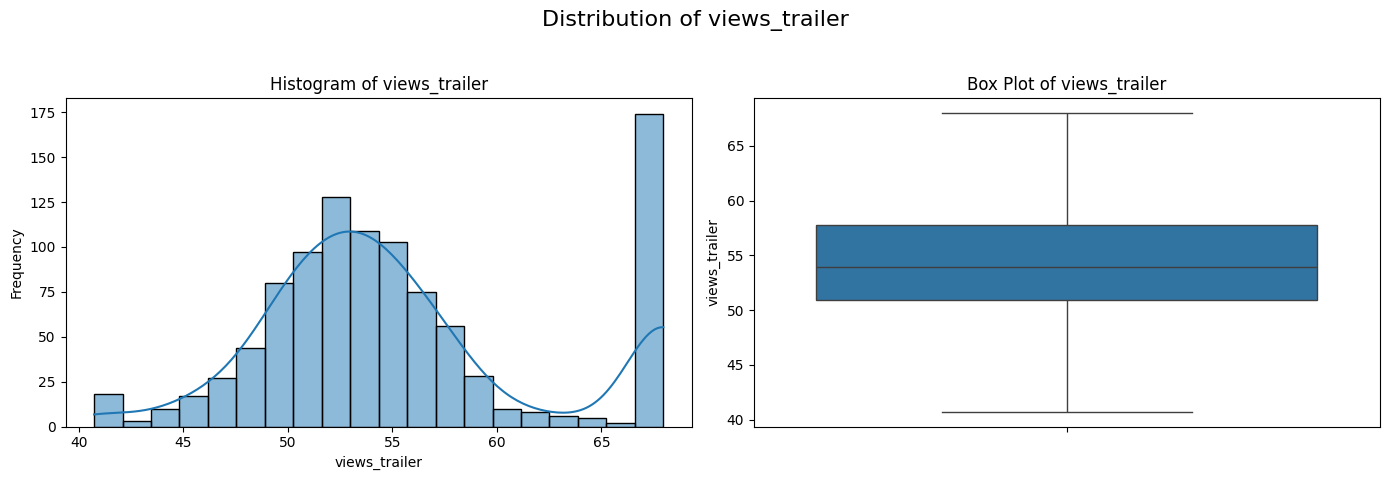

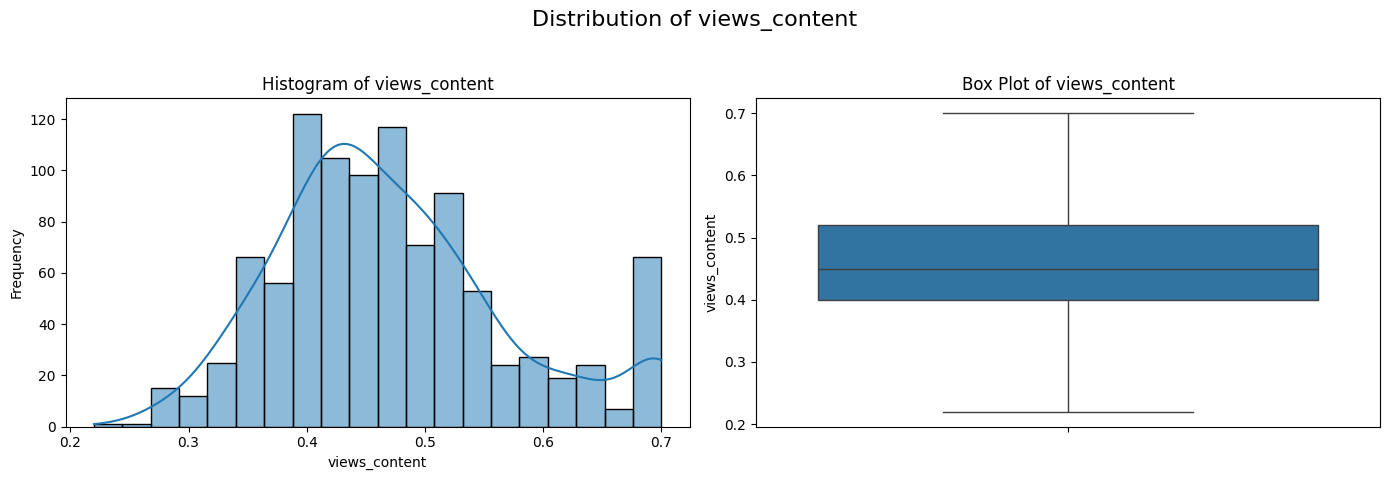

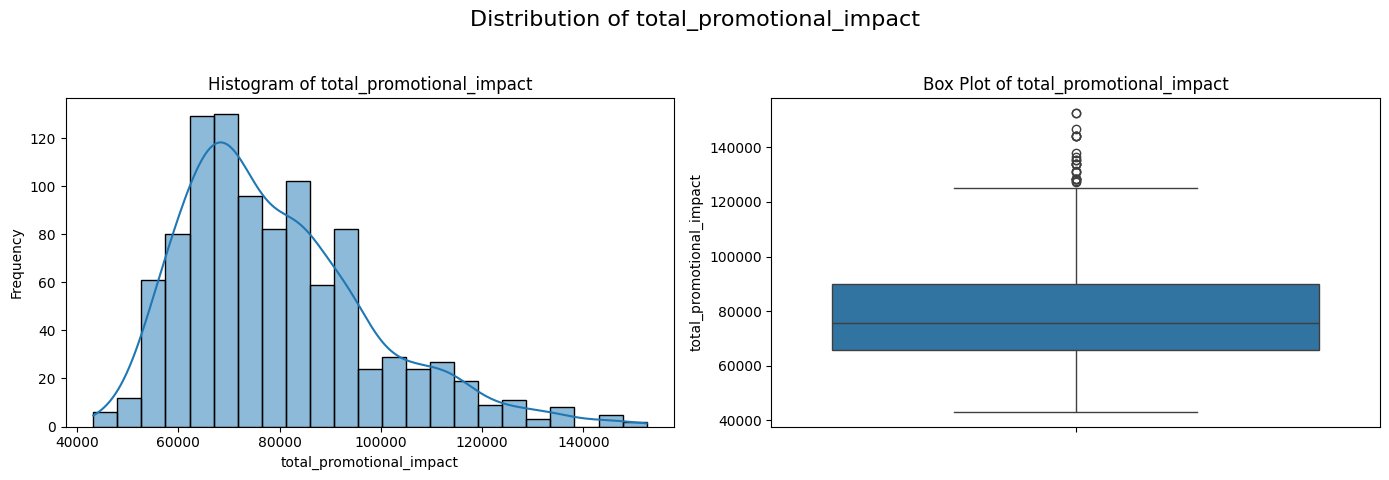

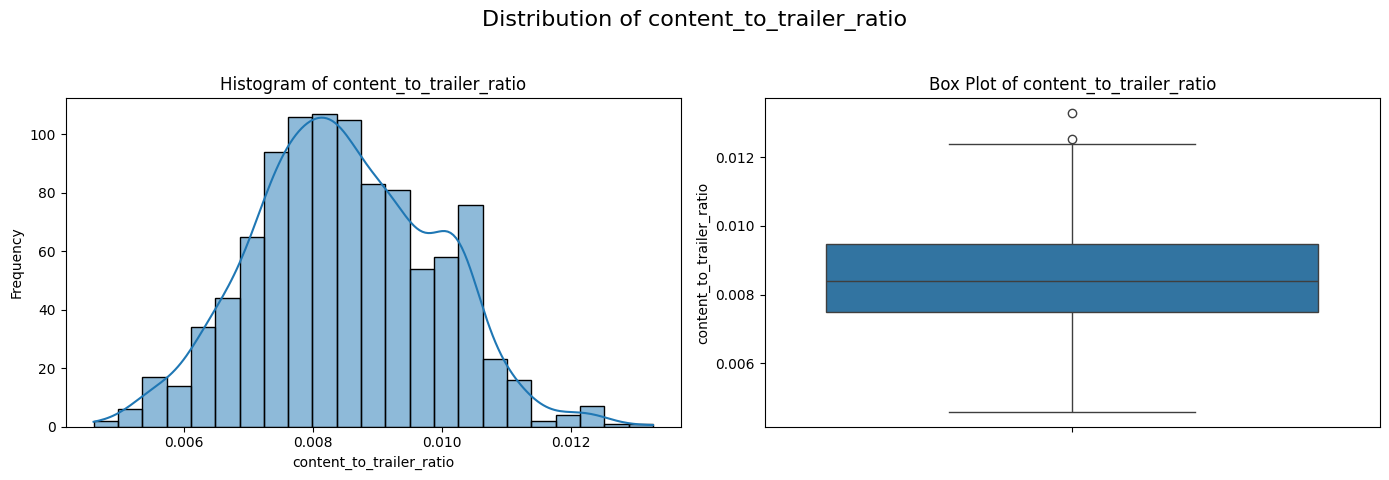

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

print("Visualizing numerical column distributions (Histograms and Box Plots):")

for col in numerical_cols:
    if df[col].nunique() > 10:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Distribution of {col}', fontsize=16)


        sns.histplot(df[col], kde=True, ax=axes[0])
        axes[0].set_title(f'Histogram of {col}')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frequency')


        sns.boxplot(y=df[col], ax=axes[1])
        axes[1].set_title(f'Box Plot of {col}')
        axes[1].set_ylabel(col)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    else:
        print(f"Skipping detailed numerical plot for '{col}' as it has few unique values (might be categorical in nature).")
        print(f"Value counts for '{col}':\n{df[col].value_counts()}\n")

Visualizing categorical column distributions (Count Plots):



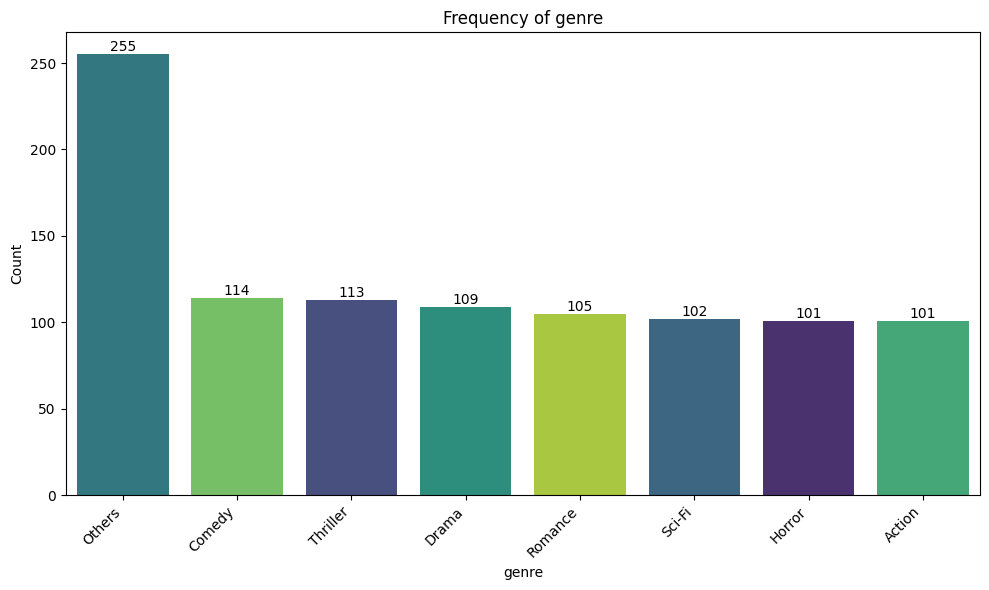

Value counts for 'genre':
genre
Others      255
Comedy      114
Thriller    113
Drama       109
Romance     105
Sci-Fi      102
Horror      101
Action      101
Name: count, dtype: int64

------------------------------



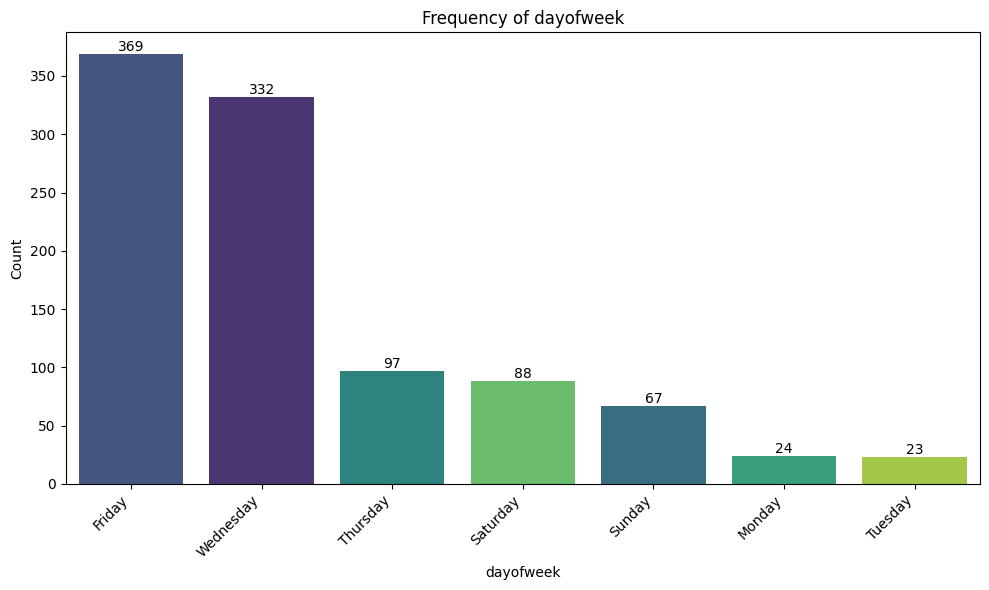

Value counts for 'dayofweek':
dayofweek
Friday       369
Wednesday    332
Thursday      97
Saturday      88
Sunday        67
Monday        24
Tuesday       23
Name: count, dtype: int64

------------------------------



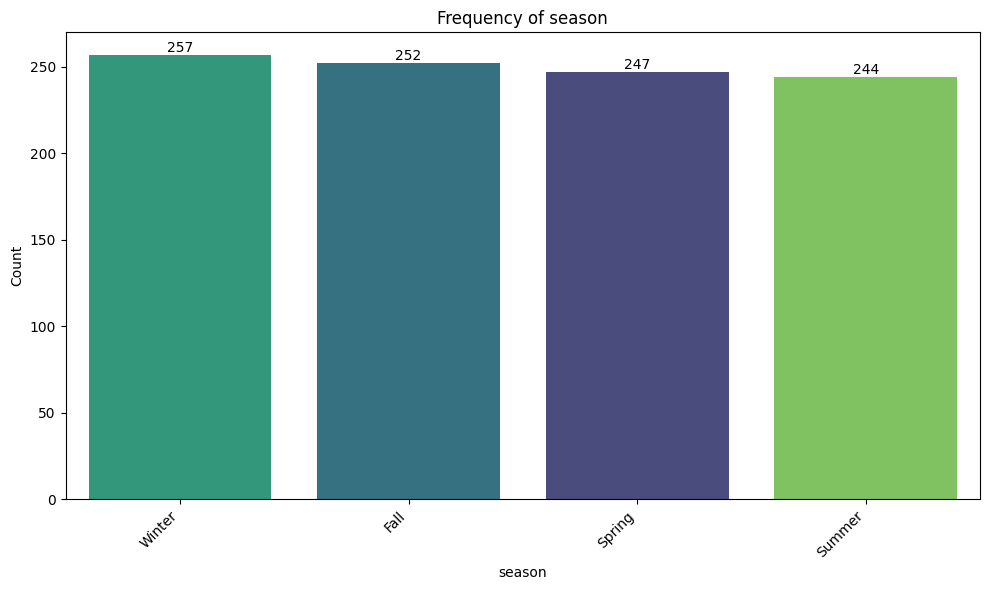

Value counts for 'season':
season
Winter    257
Fall      252
Spring    247
Summer    244
Name: count, dtype: int64

------------------------------



In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


categorical_cols = df.select_dtypes(include='object').columns

print("Visualizing categorical column distributions (Count Plots):\n")

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(x=col, data=df, palette='viridis', hue=col, legend=False, order=df[col].value_counts().index)
    plt.title(f'Frequency of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')


    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

    plt.tight_layout()
    plt.show()

    print(f"Value counts for '{col}':")
    print(df[col].value_counts())
    print("\n" + "-"*30 + "\n")

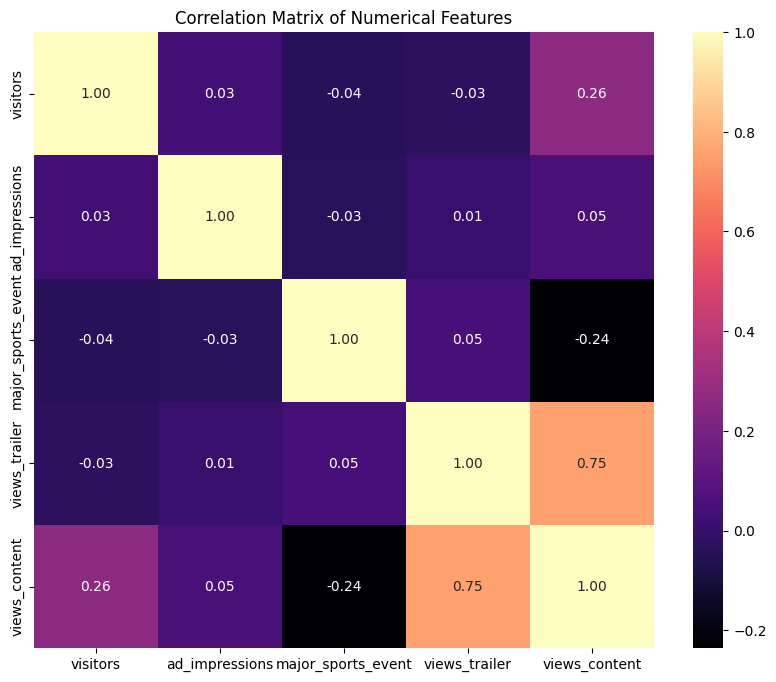

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='magma', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


### Bivariate Analysis: Numerical-Numerical (Scatter Plots)


Visualizing key numerical-numerical relationships with scatter plots:


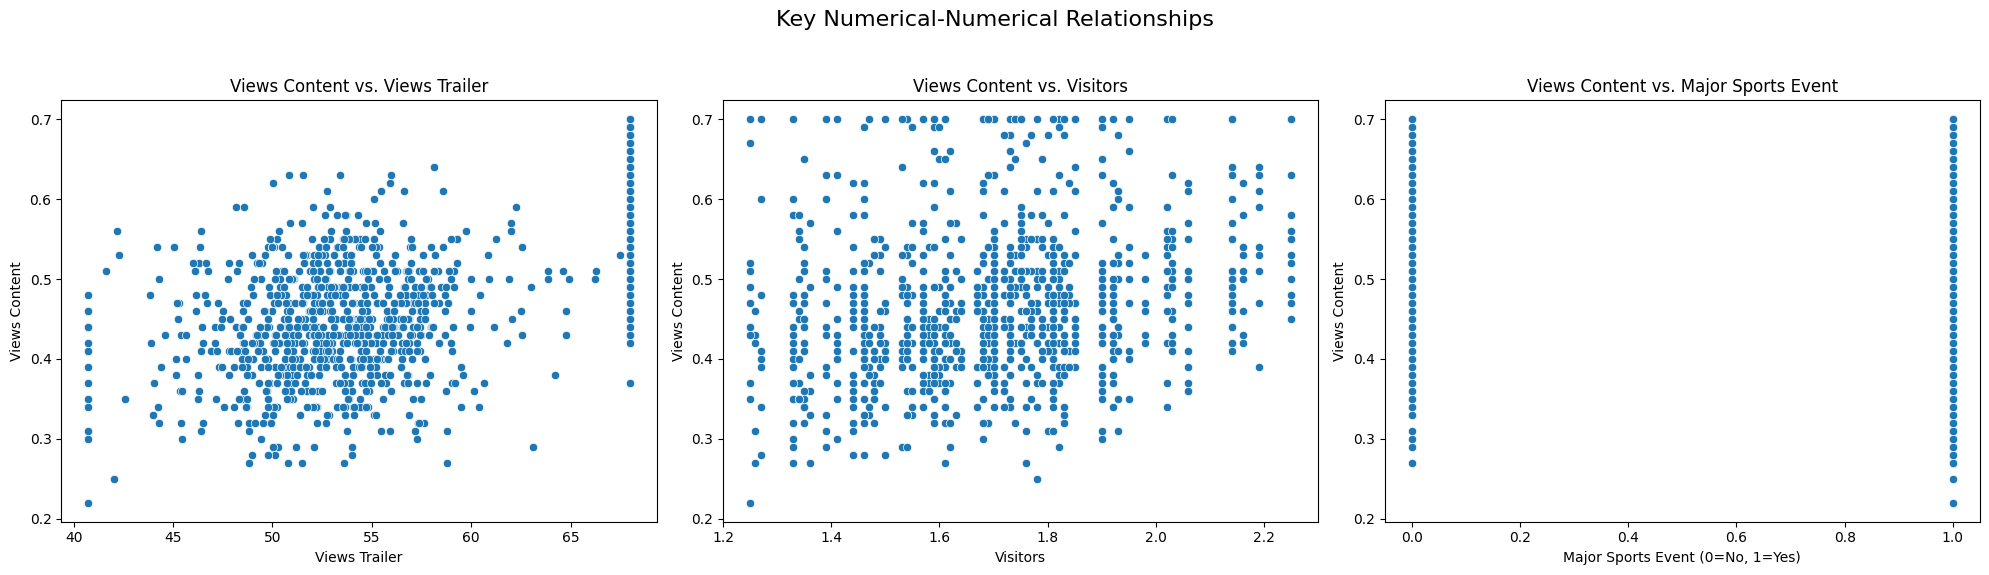

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Visualizing key numerical-numerical relationships with scatter plots:")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Key Numerical-Numerical Relationships', fontsize=16)


sns.scatterplot(x='views_trailer', y='views_content', data=df, ax=axes[0])
axes[0].set_title('Views Content vs. Views Trailer')
axes[0].set_xlabel('Views Trailer')
axes[0].set_ylabel('Views Content')


sns.scatterplot(x='visitors', y='views_content', data=df, ax=axes[1])
axes[1].set_title('Views Content vs. Visitors')
axes[1].set_xlabel('Visitors')
axes[1].set_ylabel('Views Content')


sns.scatterplot(x='major_sports_event', y='views_content', data=df, ax=axes[2])
axes[2].set_title('Views Content vs. Major Sports Event')
axes[2].set_xlabel('Major Sports Event (0=No, 1=Yes)')
axes[2].set_ylabel('Views Content')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Bivariate Analysis: Categorical-Categorical Columns


Visualizing key categorical-categorical relationships in 2 subplots:

Cross-tabulation for Genre and Day of Week:


genre,Action,Comedy,Drama,Horror,Others,Romance,Sci-Fi,Thriller
dayofweek,,,,,,,,
Friday,33,37,39,36,93,48,40,43
Monday,4,2,4,2,8,1,1,2
Saturday,8,12,8,9,21,9,15,6
Sunday,8,5,3,5,19,5,8,14
Thursday,12,11,9,10,28,10,5,12
Tuesday,1,2,3,5,8,2,1,1
Wednesday,35,45,43,34,78,30,32,35



Cross-tabulation for Season and Day of Week:


season,Fall,Spring,Summer,Winter
dayofweek,,,,
Friday,94,90,92,93
Monday,9,4,7,4
Saturday,16,26,27,19
Sunday,18,21,9,19
Thursday,18,22,25,32
Tuesday,8,4,2,9
Wednesday,89,80,82,81


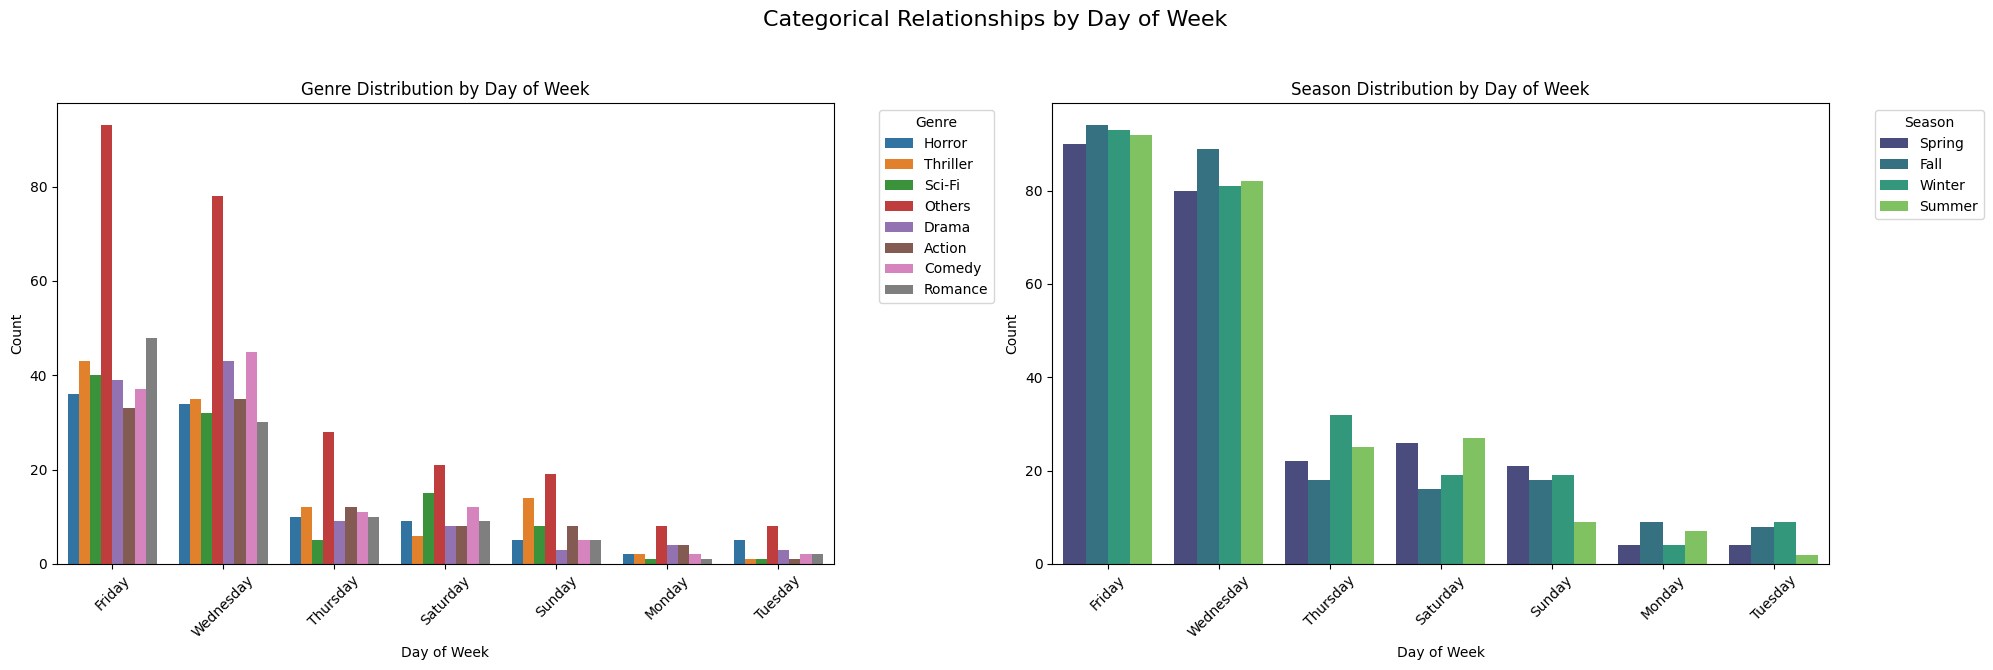

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = df.select_dtypes(include='object').columns

print("Visualizing key categorical-categorical relationships in 2 subplots:")

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Categorical Relationships by Day of Week', fontsize=16)


if 'genre' in categorical_cols and 'dayofweek' in categorical_cols:
    sns.countplot(x='dayofweek', hue='genre', data=df, palette='tab10', order=df['dayofweek'].value_counts().index, ax=axes[0])
    axes[0].set_title('Genre Distribution by Day of Week')
    axes[0].set_xlabel('Day of Week')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
    print("\nCross-tabulation for Genre and Day of Week:")
    display(pd.crosstab(df['dayofweek'], df['genre']))


if 'season' in categorical_cols and 'dayofweek' in categorical_cols:
    sns.countplot(x='dayofweek', hue='season', data=df, palette='viridis', order=df['dayofweek'].value_counts().index, ax=axes[1])
    axes[1].set_title('Season Distribution by Day of Week')
    axes[1].set_xlabel('Day of Week')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')
    print("\nCross-tabulation for Season and Day of Week:")
    display(pd.crosstab(df['dayofweek'], df['season']))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Bivariate Analysis: Numerical-Categorical Columns


Visualizing 'views_content' and 'visitors' distribution across categorical features:


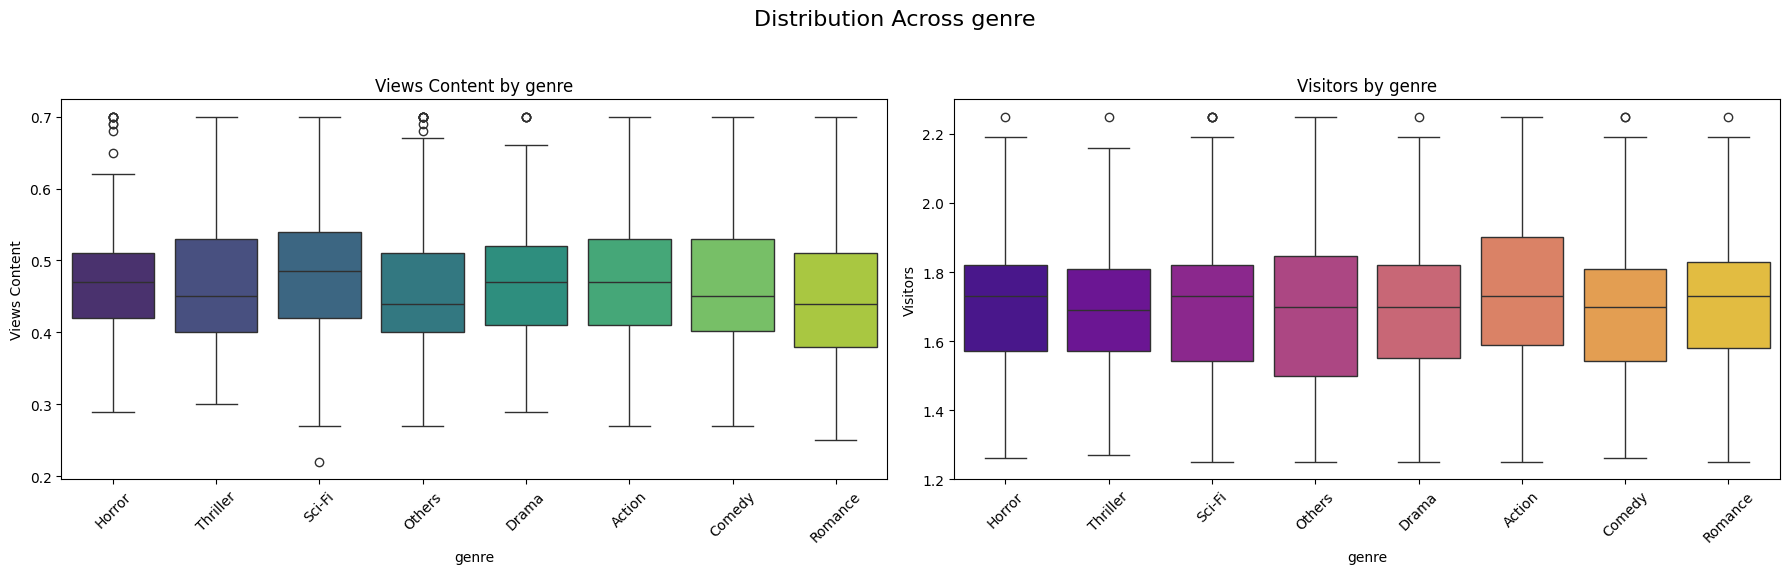

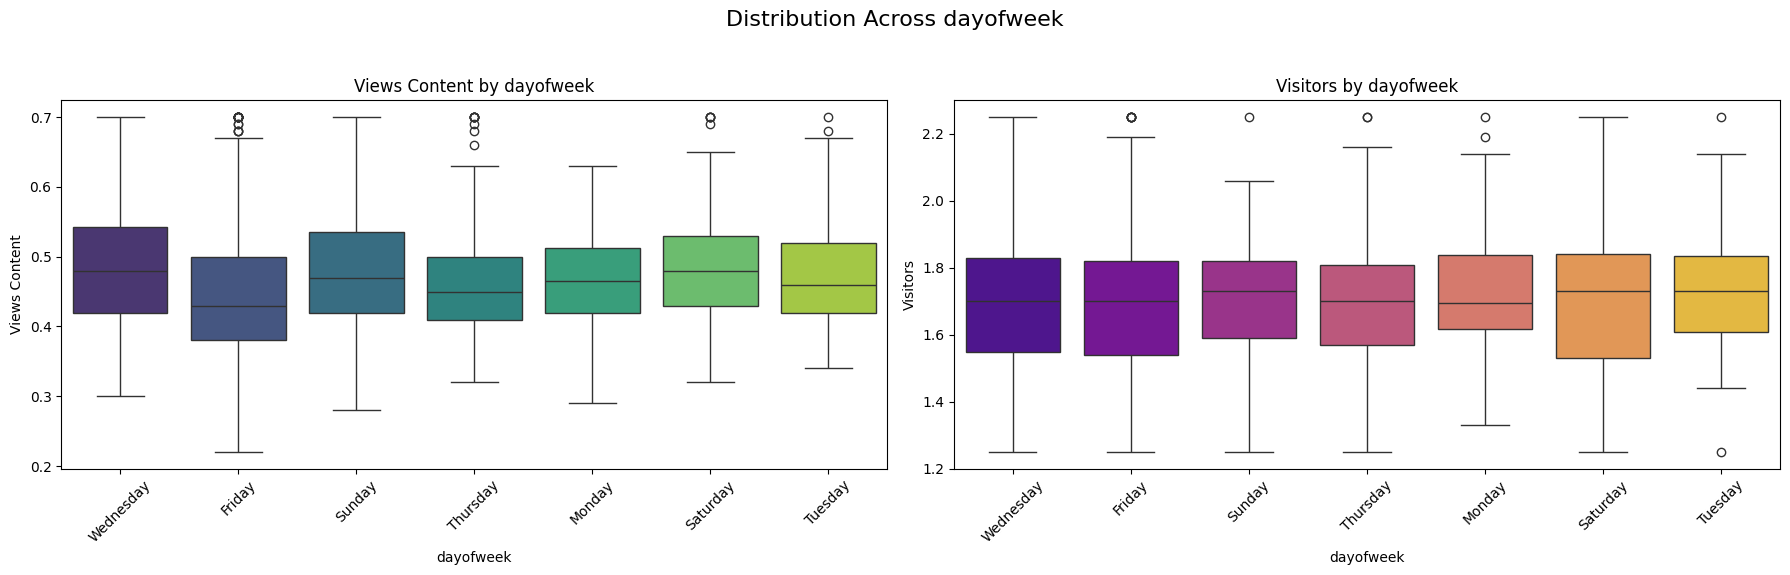

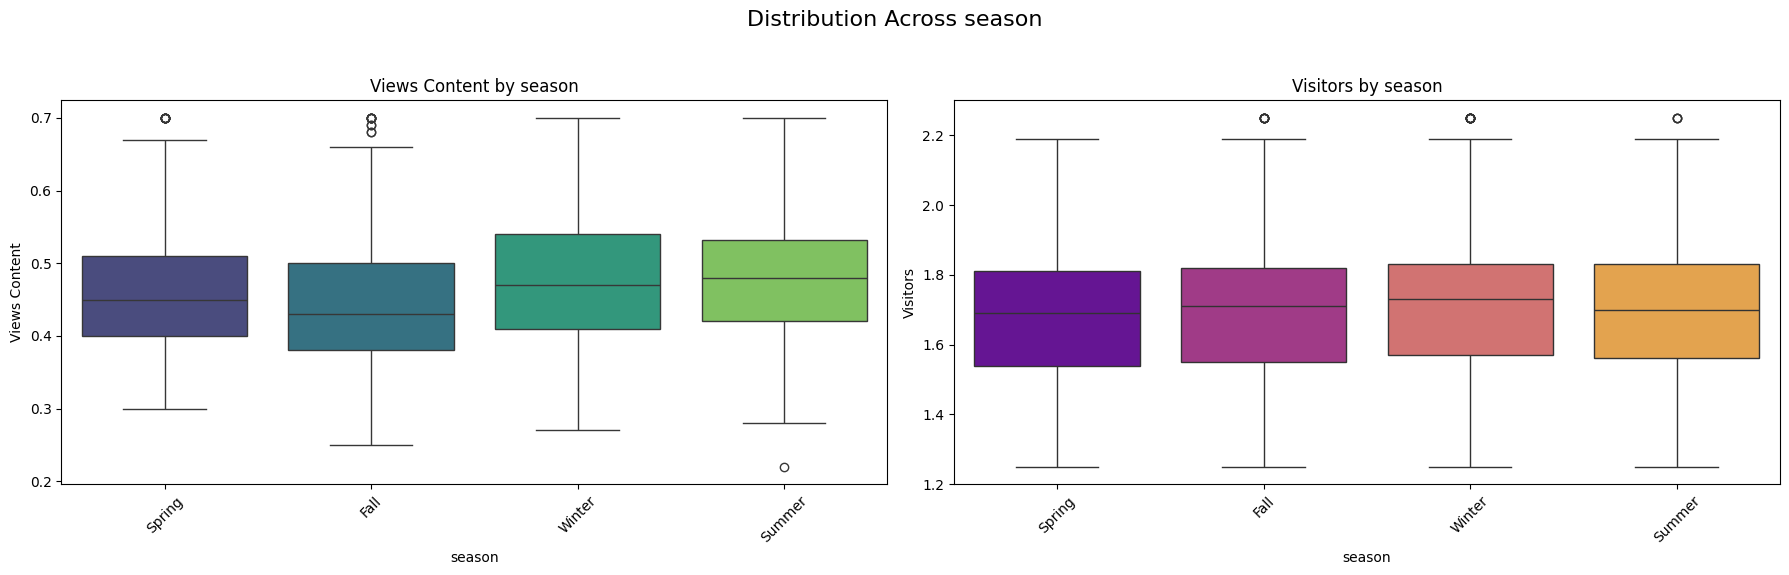

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

categorical_cols = df.select_dtypes(include='object').columns

print("Visualizing 'views_content' and 'visitors' distribution across categorical features:")
for col in categorical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'Distribution Across {col}', fontsize=16)


    sns.boxplot(x=col, y='views_content', data=df, palette='viridis', hue=col, legend=False, ax=axes[0])
    axes[0].set_title(f'Views Content by {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Views Content')
    axes[0].tick_params(axis='x', rotation=45)

    sns.boxplot(x=col, y='visitors', data=df, palette='plasma', hue=col, legend=False, ax=axes[1])
    axes[1].set_title(f'Visitors by {col}')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Visitors')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

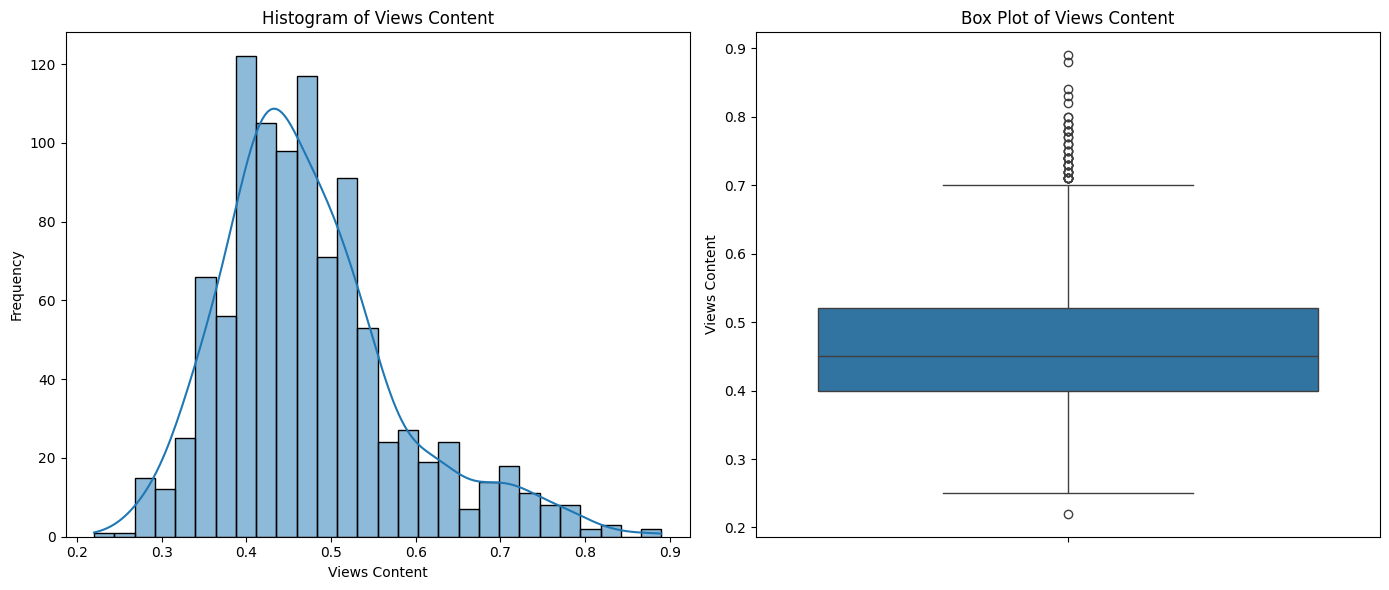

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Histogram for views_content
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(df['views_content'], kde=True)
plt.title('Histogram of Views Content')
plt.xlabel('Views Content')
plt.ylabel('Frequency')

# Box Plot for views_content
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=df['views_content'])
plt.title('Box Plot of Views Content')
plt.ylabel('Views Content')

plt.tight_layout()
plt.show()

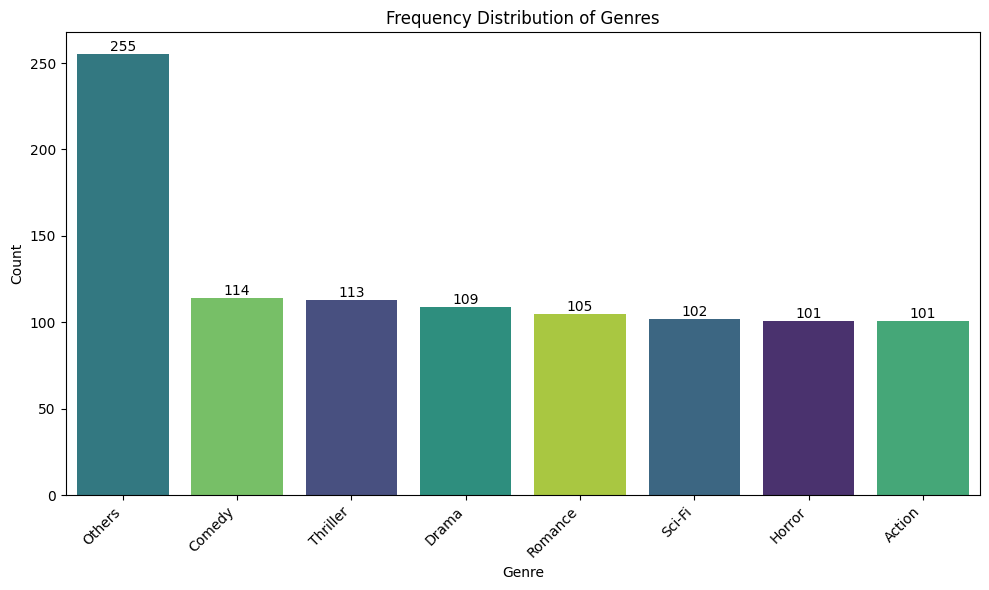

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='genre', data=df, palette='viridis', hue='genre', legend=False, order=df['genre'].value_counts().index)
plt.title('Frequency Distribution of Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

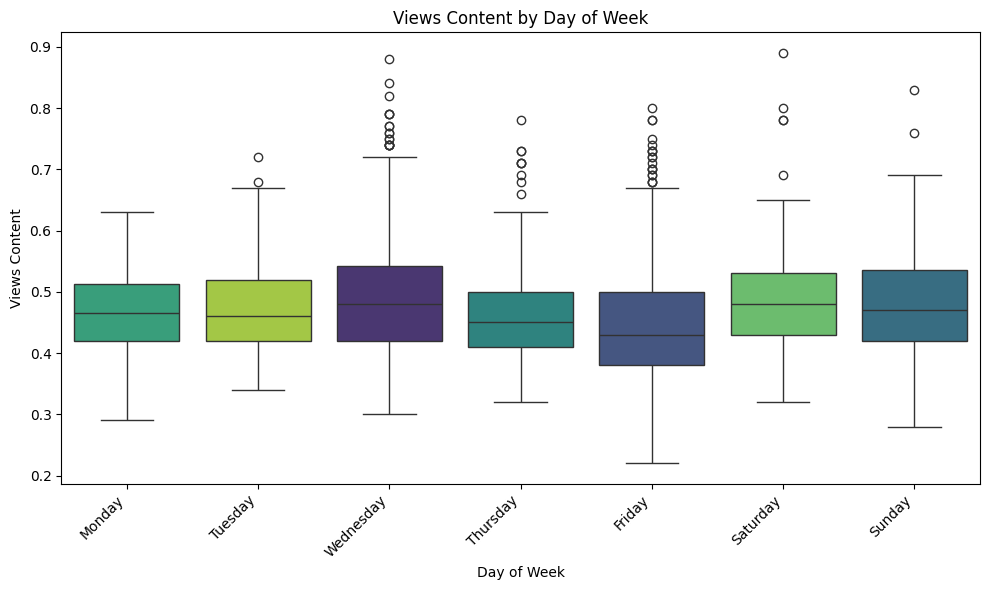

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='dayofweek', y='views_content', data=df, palette='viridis', hue='dayofweek', legend=False, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Views Content by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Views Content')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

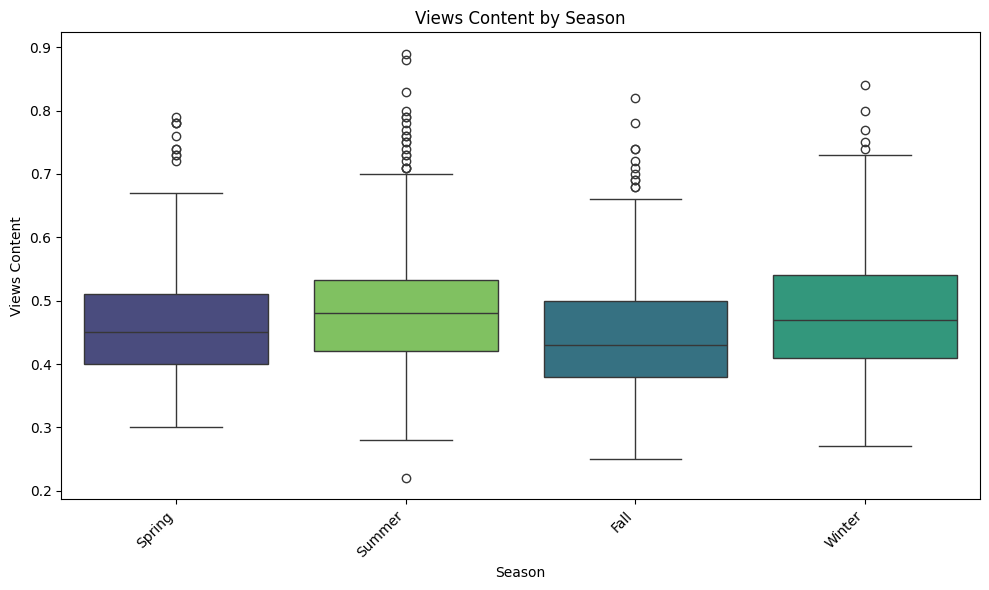

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='season', y='views_content', data=df, palette='viridis', hue='season', legend=False, order=['Spring', 'Summer', 'Fall', 'Winter'])
plt.title('Views Content by Season')
plt.xlabel('Season')
plt.ylabel('Views Content')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

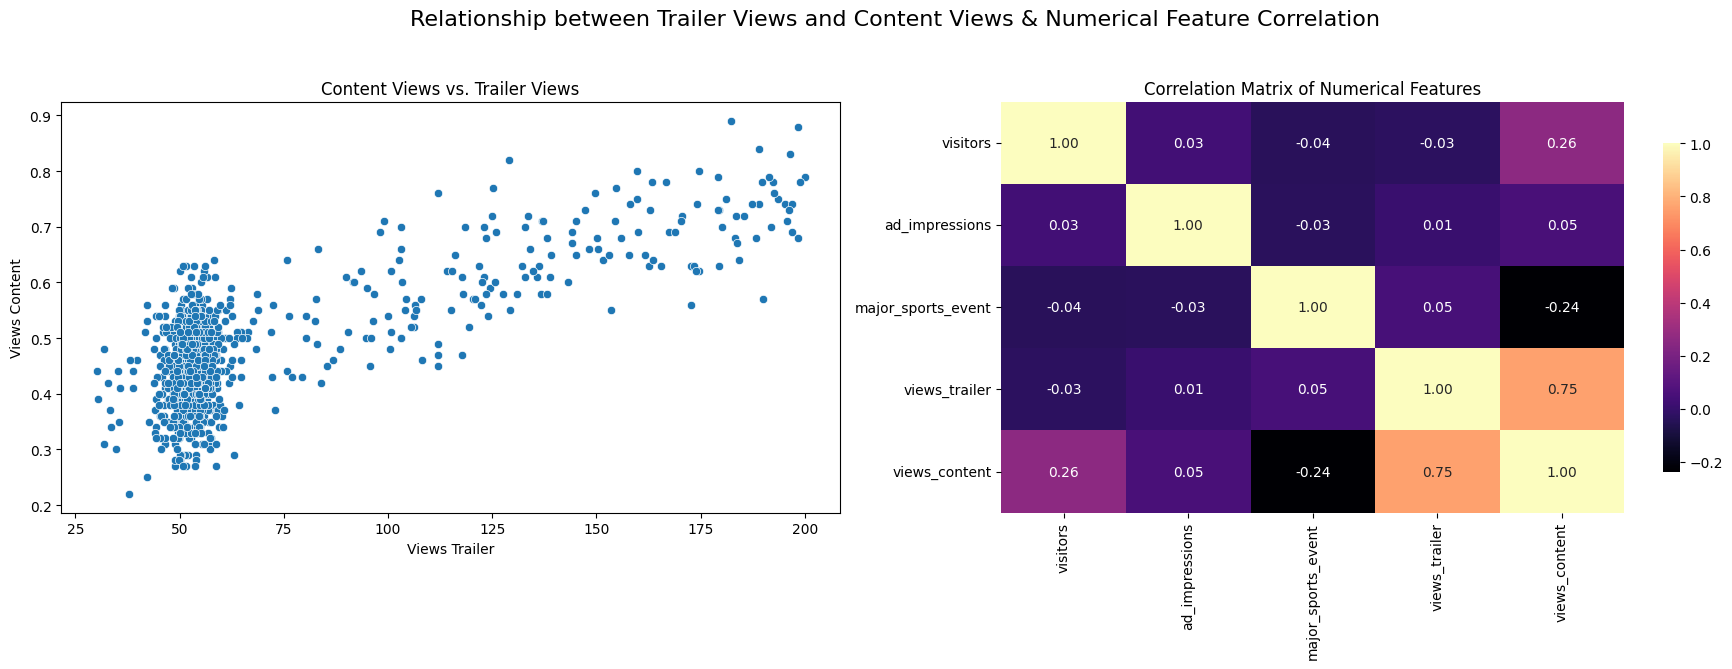

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Relationship between Trailer Views and Content Views & Numerical Feature Correlation', fontsize=16)


sns.scatterplot(x='views_trailer', y='views_content', data=df, ax=axes[0])
axes[0].set_title('Content Views vs. Trailer Views')
axes[0].set_xlabel('Views Trailer')
axes[0].set_ylabel('Views Content')


sns.heatmap(correlation_matrix, annot=True, cmap='magma', fmt=".2f", ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlation Matrix of Numerical Features')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [31]:
print("DataFrame shape before checking for duplicates:", df.shape)
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

df = df.drop_duplicates()

print("DataFrame shape after removing duplicates:", df.shape)

DataFrame shape before checking for duplicates: (1000, 8)
Number of duplicate rows found: 0
DataFrame shape after removing duplicates: (1000, 8)


In [32]:
print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values)

print("\nPercentage of missing values per column:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

Missing values per column:
visitors              0
ad_impressions        0
major_sports_event    0
genre                 0
dayofweek             0
season                0
views_trailer         0
views_content         0
dtype: int64

Percentage of missing values per column:
visitors              0.0
ad_impressions        0.0
major_sports_event    0.0
genre                 0.0
dayofweek             0.0
season                0.0
views_trailer         0.0
views_content         0.0
dtype: float64


In [33]:
import numpy as np

print("Descriptive statistics before outlier treatment:")
display(df.describe())

numerical_cols = ['visitors', 'ad_impressions', 'views_trailer', 'views_content']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nOutlier analysis for '{col}':")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")

    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f"  Number of outliers: {outliers_count}")


    if outliers_count > 0:
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        print(f"  Outliers in '{col}' have been capped at {lower_bound:.2f} (lower) and {upper_bound:.2f} (upper).")
    else:
        print(f"  No outliers found or handled for '{col}'.")

print("\nDescriptive statistics after outlier treatment:")
display(df.describe())

Descriptive statistics before outlier treatment:


,visitors,ad_impressions,major_sports_event,views_trailer,views_content
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,1.704290,1434.712290,0.400000,66.91559,0.473400
std,0.231973,289.534834,0.490143,35.00108,0.105914
min,1.250000,1010.870000,0.000000,30.08000,0.220000
25%,1.550000,1210.330000,0.000000,50.94750,0.400000
50%,1.700000,1383.580000,0.000000,53.96000,0.450000
75%,1.830000,1623.670000,1.000000,57.75500,0.520000
max,2.340000,2424.200000,1.000000,199.92000,0.890000



Outlier analysis for 'visitors':
  Q1: 1.55, Q3: 1.83, IQR: 0.28
  Lower Bound: 1.13, Upper Bound: 2.25
  Number of outliers: 20
  Outliers in 'visitors' have been capped at 1.13 (lower) and 2.25 (upper).

Outlier analysis for 'ad_impressions':
  Q1: 1210.33, Q3: 1623.67, IQR: 413.34
  Lower Bound: 590.32, Upper Bound: 2243.68
  Number of outliers: 13
  Outliers in 'ad_impressions' have been capped at 590.32 (lower) and 2243.68 (upper).

Outlier analysis for 'views_trailer':
  Q1: 50.95, Q3: 57.75, IQR: 6.81
  Lower Bound: 40.74, Upper Bound: 67.97
  Number of outliers: 189
  Outliers in 'views_trailer' have been capped at 40.74 (lower) and 67.97 (upper).

Outlier analysis for 'views_content':
  Q1: 0.40, Q3: 0.52, IQR: 0.12
  Lower Bound: 0.22, Upper Bound: 0.70
  Number of outliers: 47
  Outliers in 'views_content' have been capped at 0.22 (lower) and 0.70 (upper).

Descriptive statistics after outlier treatment:


,visitors,ad_impressions,major_sports_event,views_trailer,views_content
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.702490,1432.365530,0.400000,55.469841,0.470740
std,0.227331,282.134967,0.490143,6.887460,0.098809
min,1.250000,1010.870000,0.000000,40.736250,0.220000
25%,1.550000,1210.330000,0.000000,50.947500,0.400000
50%,1.700000,1383.580000,0.000000,53.960000,0.450000
75%,1.830000,1623.670000,1.000000,57.755000,0.520000
max,2.250000,2243.680000,1.000000,67.966250,0.700000


Visualizing numerical column distributions after outlier treatment (Box Plots):


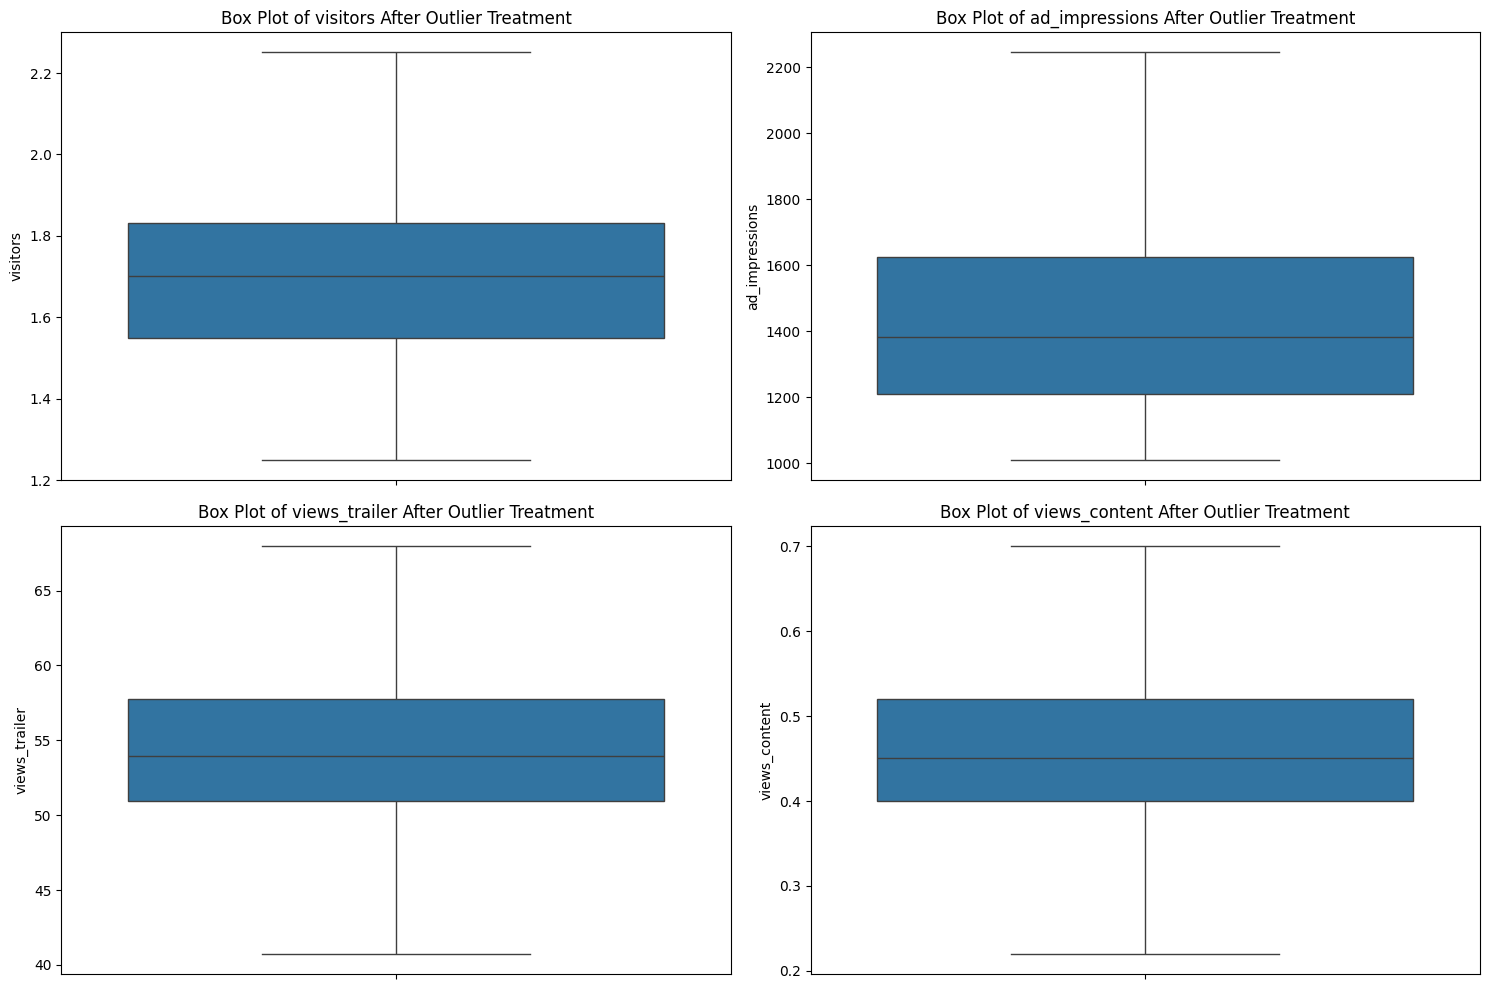

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['visitors', 'ad_impressions', 'views_trailer', 'views_content']

print("Visualizing numerical column distributions after outlier treatment (Box Plots):")

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col} After Outlier Treatment')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## Feature Engineering



In [35]:
df['total_promotional_impact'] = df['views_trailer'] * df['ad_impressions']

df['content_to_trailer_ratio'] = df['views_content'] / df['views_trailer']

print("DataFrame with new features:")
df.head()

DataFrame with new features:


,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content,total_promotional_impact,content_to_trailer_ratio
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51,63153.0270,0.008995
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32,78951.2229,0.006073
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39,52599.7206,0.008002
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44,66883.3737,0.008834
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46,83656.2303,0.008239


In [38]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder


categorical_cols = ['genre', 'dayofweek', 'season']
numerical_cols = ['visitors', 'ad_impressions', 'views_trailer', 'views_content', 'total_promotional_impact', 'content_to_trailer_ratio']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols), index=df.index)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[numerical_cols])
scaled_df = pd.DataFrame(scaled_features, columns=numerical_cols, index=df.index)

df_processed = pd.concat([
    scaled_df,
    encoded_df,
    df[['major_sports_event']]
], axis=1)

print("First few rows of the processed DataFrame:")
display(df_processed.head())

print("\nInformation about the processed DataFrame:")
df_processed.info()

First few rows of the processed DataFrame:


,visitors,ad_impressions,views_trailer,views_content,total_promotional_impact,content_to_trailer_ratio,genre_Action,genre_Comedy,genre_Drama,genre_Horror,...,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Fall,season_Spring,season_Summer,season_Winter,major_sports_event
0,-0.142991,-1.129654,0.178698,0.397531,-0.871016,0.364445,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
1,-1.067214,0.234205,-0.403811,-1.526333,-0.027559,-1.727905,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
2,-1.023204,-1.252423,-0.977604,-0.817541,-1.434452,-0.346793,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1
3,0.649201,-0.317722,-0.822171,-0.311261,-0.671855,0.249035,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
4,-1.067214,0.234205,0.052318,-0.108749,0.223639,-0.176582,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0



Information about the processed DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   visitors                  1000 non-null   float64
 1   ad_impressions            1000 non-null   float64
 2   views_trailer             1000 non-null   float64
 3   views_content             1000 non-null   float64
 4   total_promotional_impact  1000 non-null   float64
 5   content_to_trailer_ratio  1000 non-null   float64
 6   genre_Action              1000 non-null   float64
 7   genre_Comedy              1000 non-null   float64
 8   genre_Drama               1000 non-null   float64
 9   genre_Horror              1000 non-null   float64
 10  genre_Others              1000 non-null   float64
 11  genre_Romance             1000 non-null   float64
 12  genre_Sci-Fi              1000 non-null   float64
 13  genre_Thriller      

In [45]:
from sklearn.model_selection import train_test_split


X = df_processed.drop('views_content', axis=1)
y = df_processed['views_content']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shapes of the split datasets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shapes of the split datasets:
X_train shape: (700, 25)
X_test shape: (300, 25)
y_train shape: (700,)
y_test shape: (300,)


In [46]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)

model = sm.OLS(y_train, X_train_sm)
model_results = model.fit()

print("OLS model training complete.")

OLS model training complete.


In [47]:
print(model_results.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     3039.
Date:                Sun, 16 Nov 2025   Prob (F-statistic):               0.00
Time:                        10:39:53   Log-Likelihood:                 617.87
No. Observations:                 700   AIC:                            -1190.
Df Residuals:                     677   BIC:                            -1085.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [48]:
import pandas as pd

coefficients = model_results.params
std_err = model_results.bse
t_values = model_results.tvalues
p_values = model_results.pvalues

coefficients_df = pd.DataFrame({
    'Feature': coefficients.index,
    'Coefficient': coefficients.values,
    'Standard Error': std_err.values,
    't-value': t_values.values,
    'P>|t|': p_values.values
})

coefficients_df_sorted_impact = coefficients_df.reindex(coefficients_df['Coefficient'].abs().sort_values(ascending=False).index)

coefficients_df_sorted_pvalue = coefficients_df.sort_values(by='P>|t|', ascending=True)

print("\nCoefficients sorted by absolute impact (descending):")
display(coefficients_df_sorted_impact)

print("\nCoefficients sorted by P>|t| (ascending):")
display(coefficients_df_sorted_pvalue)


Coefficients sorted by absolute impact (descending):


,Feature,Coefficient,Standard Error,t-value,P>|t|
5,content_to_trailer_ratio,0.776022,0.004953,156.670608,0.000000e+00
3,views_trailer,0.628026,0.020286,30.959189,8.673409e-132
12,genre_Sci-Fi,0.023327,0.011768,1.982277,4.785211e-02
9,genre_Horror,-0.012301,0.010663,-1.153681,2.490382e-01
19,dayofweek_Tuesday,0.010737,0.022971,0.467434,6.403397e-01
24,season_Winter,-0.010390,0.006722,-1.545663,1.226533e-01
21,season_Fall,0.009011,0.007022,1.283280,1.998330e-01
4,total_promotional_impact,-0.008504,0.037736,-0.225361,8.217668e-01
2,ad_impressions,0.008059,0.032217,0.250162,8.025380e-01
15,dayofweek_Monday,-0.008052,0.022835,-0.352616,7.244863e-01



Coefficients sorted by P>|t| (ascending):


,Feature,Coefficient,Standard Error,t-value,P>|t|
5,content_to_trailer_ratio,0.776022,0.004953,156.670608,0.000000e+00
3,views_trailer,0.628026,0.020286,30.959189,8.673409e-132
12,genre_Sci-Fi,0.023327,0.011768,1.982277,4.785211e-02
24,season_Winter,-0.010390,0.006722,-1.545663,1.226533e-01
21,season_Fall,0.009011,0.007022,1.283280,1.998330e-01
9,genre_Horror,-0.012301,0.010663,-1.153681,2.490382e-01
20,dayofweek_Wednesday,-0.007414,0.008204,-0.903633,3.665117e-01
14,dayofweek_Friday,0.006859,0.008209,0.835497,4.037328e-01
13,genre_Thriller,0.007965,0.011030,0.722121,4.704692e-01
25,major_sports_event,0.006263,0.008908,0.703085,4.822446e-01


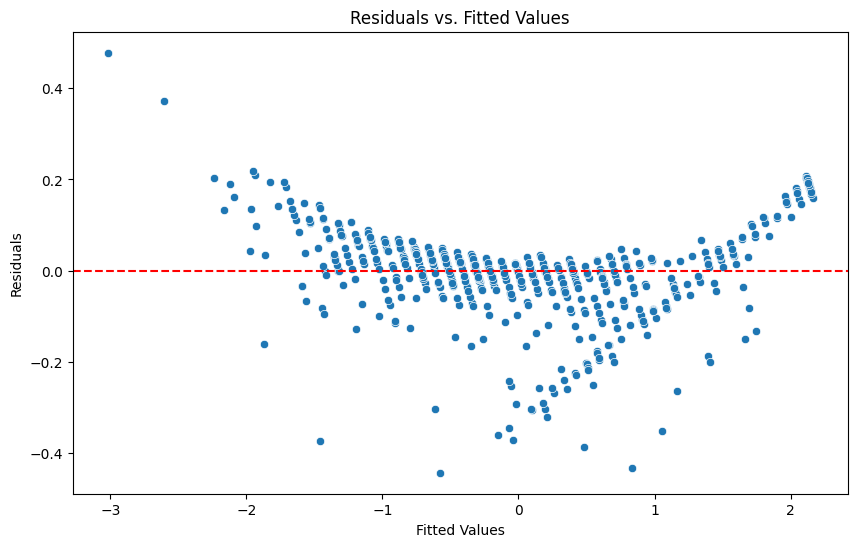

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

fitted_values = model_results.fittedvalues
residuals = model_results.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

In [59]:
from statsmodels.stats.api import het_goldfeldquandt
import numpy as np

sorted_indices = X_train_sm['views_trailer'].sort_values().index
X_train_sorted = X_train_sm.loc[sorted_indices]
y_train_sorted = y_train.loc[sorted_indices]

try:
    views_trailer_idx = X_train_sm.columns.get_loc('views_trailer')
except KeyError:
    print("Error: 'views_trailer' not found in X_train_sm columns. Please check feature names.")
    views_trailer_idx = None

if views_trailer_idx is not None:
    n_obs = len(y_train_sorted)
    split_obs = int(n_obs * 0.3)

    gq_test = het_goldfeldquandt(y_train_sorted, X_train_sorted, idx=views_trailer_idx, alternative='two-sided', split=split_obs)

    print("\nGoldfeld–Quandt Test Results (sorted by 'views_trailer'):")
    print(f"F-statistic: {gq_test[0]:.4f}")
    print(f"P-value: {gq_test[1]:.4f}")


    if gq_test[1] < 0.05:
        print("Conclusion: The p-value is less than 0.05, so we reject the null hypothesis of homoscedasticity. This indicates the presence of heteroscedasticity.")
    else:
        print("Conclusion: The p-value is greater than 0.05, so we fail to reject the null hypothesis of homoscedasticity. This indicates homoscedasticity is present.")
else:
    print("Goldfeld–Quandt Test could not be performed due to missing 'views_trailer' index.")


Goldfeld–Quandt Test Results (sorted by 'views_trailer'):
F-statistic: 2.3156
P-value: 0.0000
Conclusion: The p-value is less than 0.05, so we reject the null hypothesis of homoscedasticity. This indicates the presence of heteroscedasticity.


In [51]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["feature"] = X_train_sm.columns

vif_data["VIF"] = [variance_inflation_factor(X_train_sm.values, i)
                   for i in range(X_train_sm.shape[1])]

vif_data_sorted = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("Variance Inflation Factor (VIF) for independent variables:")
display(vif_data_sorted)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Variance Inflation Factor (VIF) for independent variables:


,feature,VIF
0,genre_Drama,inf
1,genre_Horror,inf
2,genre_Comedy,inf
3,genre_Action,inf
4,dayofweek_Monday,inf
5,dayofweek_Friday,inf
6,genre_Thriller,inf
7,genre_Sci-Fi,inf
8,genre_Romance,inf
9,genre_Others,inf


In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()

columns_to_exclude_from_vif = ['const', 'genre_Action', 'dayofweek_Monday', 'season_Fall']

X_for_vif = X_train_sm.drop(columns=columns_to_exclude_from_vif, errors='ignore')

if X_for_vif.empty:
    print("No independent variables left after excluding constant and reference categories for VIF calculation.")
else:
    features = X_for_vif.columns


    vif_values = [variance_inflation_factor(X_for_vif.values, i)
                       for i in range(X_for_vif.shape[1])]

    vif_data["feature"] = features
    vif_data["VIF"] = vif_values


    vif_data_sorted = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

    print("Variance Inflation Factor (VIF) for independent variables (after addressing multicollinearity):")
    display(vif_data_sorted)

Variance Inflation Factor (VIF) for independent variables (after addressing multicollinearity):


,feature,VIF
0,total_promotional_impact,93.601192
1,ad_impressions,68.441773
2,views_trailer,28.069782
3,dayofweek_Friday,5.224902
4,dayofweek_Wednesday,4.709703
5,genre_Others,3.211220
6,season_Winter,2.194885
7,dayofweek_Thursday,2.181178
8,major_sports_event,2.126301
9,season_Summer,2.084125


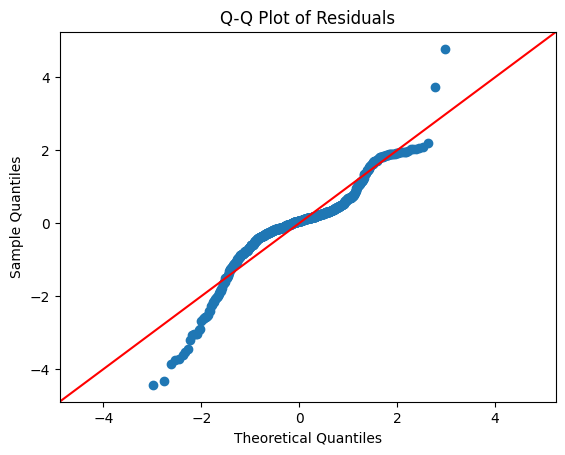

Observation: If the residuals fall along the 45-degree line, it suggests a normal distribution.
Deviations from the line, especially at the tails, indicate non-normality. For our model, we expect to see deviations given the previous statistical tests.


In [62]:
import statsmodels.api as sm
import matplotlib.pyplot as plt


residuals = model_results.resid


fig = sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

print("Observation: If the residuals fall along the 45-degree line, it suggests a normal distribution.")
print("Deviations from the line, especially at the tails, indicate non-normality. For our model, we expect to see deviations given the previous statistical tests.")

In [63]:
import statsmodels.api as sm

X_test_sm = sm.add_constant(X_test)

y_pred = model_results.predict(X_test_sm)

print("Predictions generated successfully.")
print(f"Shape of y_pred: {y_pred.shape}")

Predictions generated successfully.
Shape of y_pred: (300,)


In [64]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r_squared = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print(f"R-squared: {r_squared:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

R-squared: 0.9906
Mean Absolute Error (MAE): 0.0629
Mean Squared Error (MSE): 0.0093
Root Mean Squared Error (RMSE): 0.0967


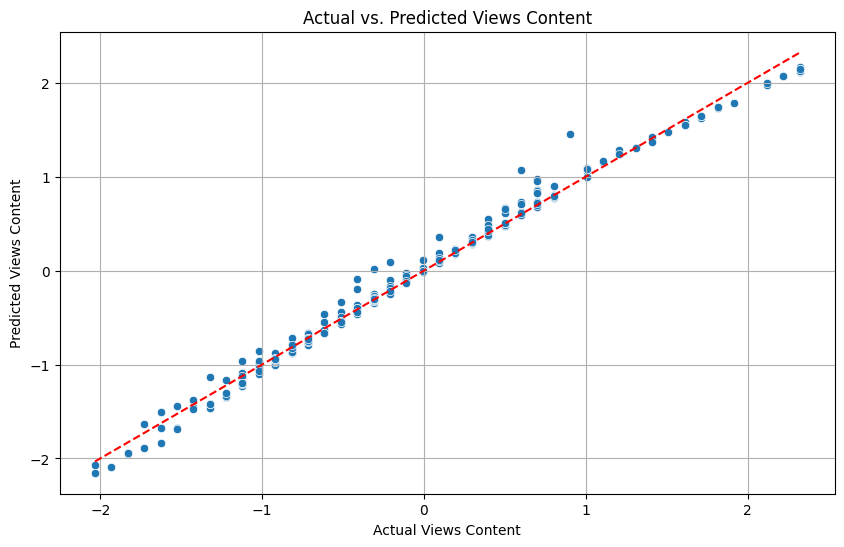

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs. Predicted Views Content')
plt.xlabel('Actual Views Content')
plt.ylabel('Predicted Views Content')
plt.grid(True)
plt.show()